# tarea 5 - cnn para clasificar ropa

voy a entrenar una cnn con imágenes de ropa de Fashion-MNIST

para no tardar tanto uso 30 mil imágenes y solamente 5 épocas

usé [Fashion-MNIST](https://www.tensorflow.org/api_docs/python/tf/keras/datasets/fashion_mnist/load_data), este [ejemplo con cnn](https://blog.tensorflow.org/2018/04/fashion-mnist-with-tfkeras.html) y la ayuda de [Conv2D](https://keras.io/api/layers/convolution_layers/convolution2d/)

## cargando los datos

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix

tf.random.set_seed(42)

nombres_clases = [
    'camiseta', 'pantalón', 'suéter', 'vestido', 'abrigo',
    'sandalia', 'camisa', 'tenis', 'bolsa', 'botín'
]

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


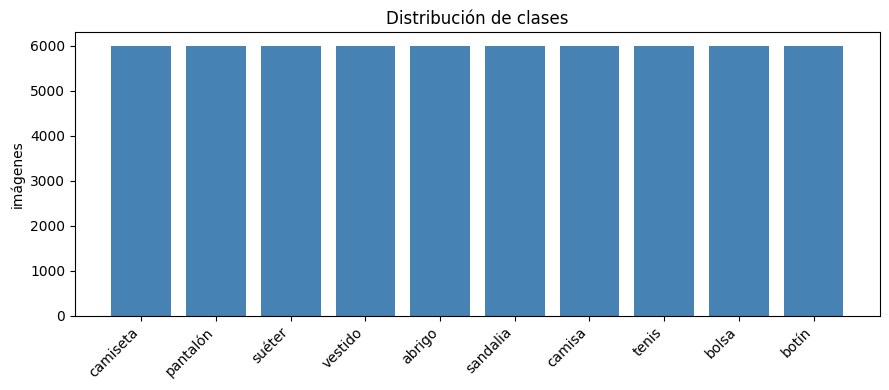

((60000, 28, 28), (10000, 28, 28))

In [2]:
(imagenes_totales, etiquetas_totales), (imagenes_prueba, etiquetas_prueba) = (
    tf.keras.datasets.fashion_mnist.load_data()
)

conteo_clases = np.bincount(etiquetas_totales)
plt.figure(figsize=(9, 4))
plt.bar(nombres_clases, conteo_clases, color='steelblue')
plt.xticks(rotation=45, ha='right')
plt.ylabel('imágenes')
plt.title('Distribución de clases')
plt.tight_layout()
plt.show()

imagenes_totales.shape, imagenes_prueba.shape

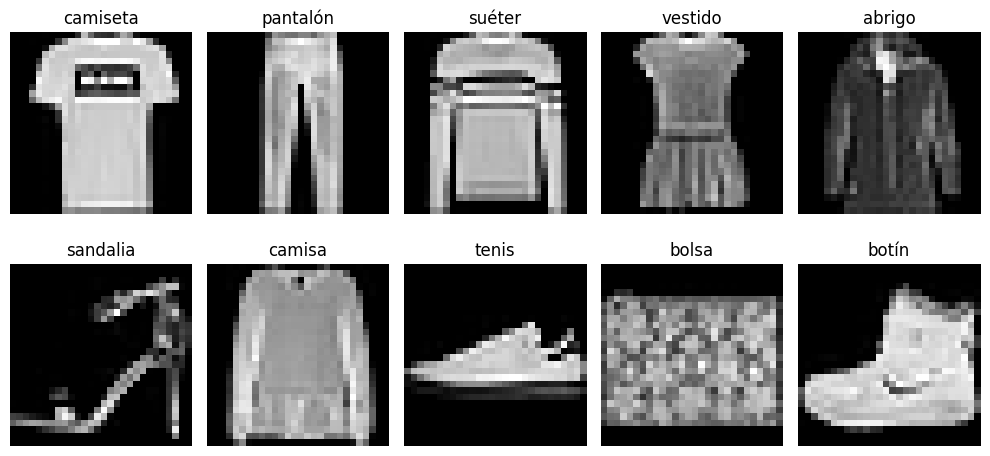

In [3]:
# veo las primeras imágenes, nada más para saber cómo vienen
figura, ejes = plt.subplots(2, 5, figsize=(10, 5))
for numero in range(10):
    eje = ejes.ravel()[numero]
    eje.imshow(imagenes_totales[numero], cmap='gray')
    eje.set_title(nombres_clases[etiquetas_totales[numero]])
    eje.axis('off')
plt.tight_layout()
plt.show()

## preparando las imágenes

divido los pixeles entre 255 y separo una parte para validación

In [4]:
imagenes_entrenamiento = imagenes_totales[:30000].astype('float32') / 255.0
etiquetas_entrenamiento = etiquetas_totales[:30000]
imagenes_validacion = imagenes_totales[30000:36000].astype('float32') / 255.0
etiquetas_validacion = etiquetas_totales[30000:36000]
imagenes_prueba = imagenes_prueba.astype('float32') / 255.0

imagenes_entrenamiento = imagenes_entrenamiento[..., np.newaxis]
imagenes_validacion = imagenes_validacion[..., np.newaxis]
imagenes_prueba = imagenes_prueba[..., np.newaxis]

imagenes_entrenamiento.shape, imagenes_validacion.shape, imagenes_prueba.shape

((30000, 28, 28, 1), (6000, 28, 28, 1), (10000, 28, 28, 1))

## armando la cnn

puse dos capas de convolución y al final una salida para las 10 prendas

In [5]:
modelo = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(.30),
    layers.Dense(10, activation='softmax')
])

modelo.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## entrenamiento

solo uso 5 épocas para que no se haga tan tardado

In [6]:
# cinco épocas me alcanzan para ver el comportamiento sin hacer muy larga la prueba
historial = modelo.fit(
    imagenes_entrenamiento, etiquetas_entrenamiento,
    epochs=5, batch_size=64,
    validation_data=(imagenes_validacion, etiquetas_validacion),
    verbose=1
)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7418 - loss: 0.7059 - val_accuracy: 0.8352 - val_loss: 0.4570
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8364 - loss: 0.4552 - val_accuracy: 0.8538 - val_loss: 0.3898
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8596 - loss: 0.3920 - val_accuracy: 0.8690 - val_loss: 0.3530
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8693 - loss: 0.3590 - val_accuracy: 0.8802 - val_loss: 0.3242
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8765 - loss: 0.3341 - val_accuracy: 0.8708 - val_loss: 0.3352


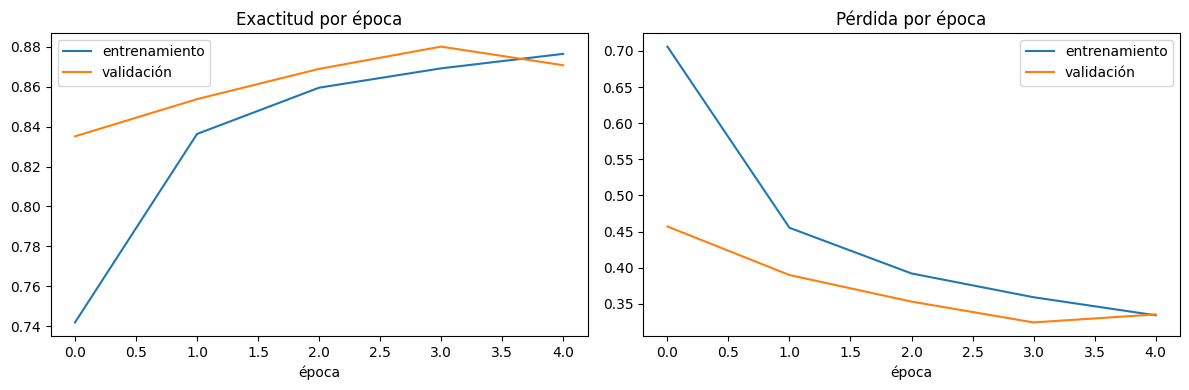

In [7]:
figura, ejes = plt.subplots(1, 2, figsize=(12, 4))
ejes[0].plot(historial.history['accuracy'], label='entrenamiento')
ejes[0].plot(historial.history['val_accuracy'], label='validación')
ejes[0].set_title('Exactitud por época')
ejes[0].set_xlabel('época')
ejes[0].legend()

ejes[1].plot(historial.history['loss'], label='entrenamiento')
ejes[1].plot(historial.history['val_loss'], label='validación')
ejes[1].set_title('Pérdida por época')
ejes[1].set_xlabel('época')
ejes[1].legend()
plt.tight_layout()
plt.show()

## resultados

In [8]:
perdida_prueba, exactitud_prueba = modelo.evaluate(
    imagenes_prueba, etiquetas_prueba, verbose=0
)
probabilidades = modelo.predict(imagenes_prueba, verbose=0)
predicciones = np.argmax(probabilidades, axis=1)

round(exactitud_prueba, 4), round(perdida_prueba, 4)

{'exactitud': 0.8648, 'perdida': 0.3566}

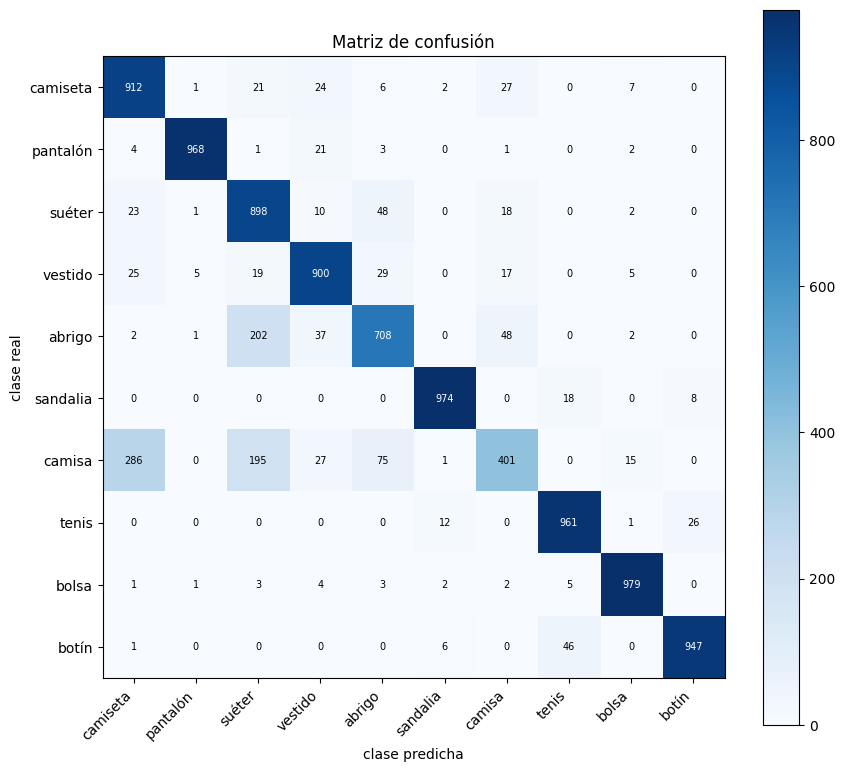

In [9]:
matriz = confusion_matrix(etiquetas_prueba, predicciones)

plt.figure(figsize=(8, 7))
plt.imshow(matriz, cmap='Blues')
plt.xticks(range(10), nombres_clases, rotation=45)
plt.yticks(range(10), nombres_clases)
plt.xlabel('predicción')
plt.ylabel('real')
plt.title('matriz de confusión')
plt.show()

## viendo algunas predicciones

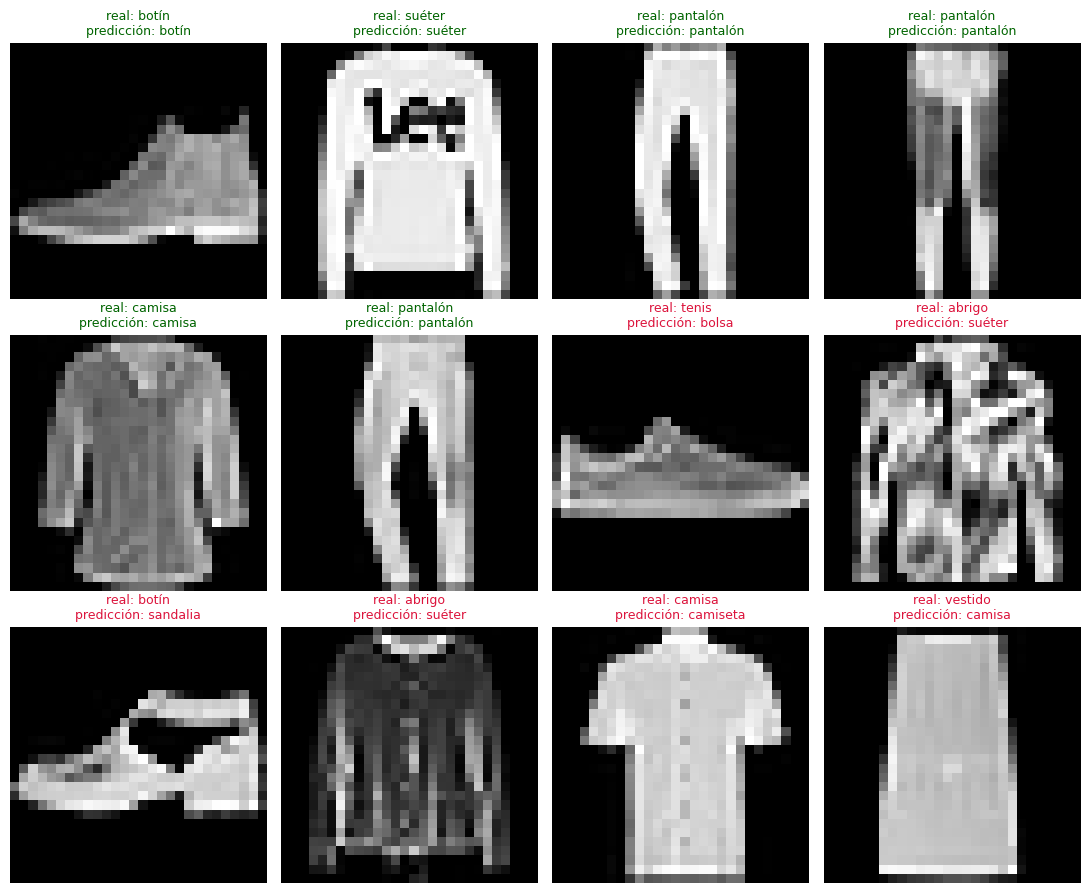

In [10]:
# agarro las primeras 12, aquí pueden salir aciertos y errores
figura, ejes = plt.subplots(3, 4, figsize=(11, 9))
for posicion in range(12):
    eje = ejes.ravel()[posicion]
    real = etiquetas_prueba[posicion]
    predicha = predicciones[posicion]
    eje.imshow(imagenes_prueba[posicion].squeeze(), cmap='gray')
    eje.set_title(f'{nombres_clases[real]} / {nombres_clases[predicha]}', fontsize=9)
    eje.axis('off')
plt.tight_layout()
plt.show()

## conclusión

la red sí logra separar bastante bien las prendas usando solamente los pixeles

los errores se dan más entre prendas que tienen formas parecidas, también hay que considerar que las imágenes son pequeñas y no tienen color

con más datos o más épocas probablemente mejoraría pero también tardaría más

In [11]:
cantidad_errores = (predicciones != etiquetas_prueba).sum()
round(exactitud_prueba, 4), cantidad_errores

{'exactitud final': 0.8648,
 'clase real con más error': 'camisa',
 'la tomó como': 'camiseta'}